Right now we have one train/test split. The problem is that one split can be lucky or unlucky depending on what happened in that specific period. January 2024 had a polar vortex — that made your test set unusually hard.
Backtesting solves this by testing your model across many different time windows so you get a honest picture of average performance.

In [3]:
import os
os.chdir(r'C:\Projects\lmp-forecaster')

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load feature matrix
df = pd.read_csv(
    'data/features/feature_matrix_v1.csv',
    parse_dates=['Time'],
    index_col='Time'
)

TARGET = 'LMP'
FEATURES = [col for col in df.columns if col not in [
    'LMP', 'Energy', 'Congestion', 'Loss'
]]

X = df[FEATURES]
y = df[TARGET]

print("Loaded:", X.shape)

Loaded: (17329, 33)


Understand Walk-Forward Validation:

```
Fold 1:  [TRAIN: Jan–Apr 2023] [TEST: May 2023]
Fold 2:  [TRAIN: Jan–Jun 2023] [TEST: Jul 2023]
Fold 3:  [TRAIN: Jan–Aug 2023] [TEST: Sep 2023]
Fold 4:  [TRAIN: Jan–Oct 2023] [TEST: Nov 2023]
Fold 5:  [TRAIN: Jan–Dec 2023] [TEST: Jan 2024]
...
```
Each fold:

- Training set grows (always starts from beginning)
- Test set moves forward in time
- Model never sees future data during training

This gives multiple independent performance measurements across different market conditions — summer heat waves, winter cold snaps, normal periods — so your final score is a reliable average, not a lucky/unlucky single split.

In [4]:
# --- Run the Walk-Forward Backtes ---

# TimeSeriesSplit — the correct CV method for time series
# n_splits=8 gives us 8 independent test windows
tscv = TimeSeriesSplit(n_splits=8, gap=24)
# gap=24 means skip 24 rows between train and test
# This prevents the model from using "almost today" data

fold_results = []

print("Running walk-forward backtest...\n")
print(f"{'Fold':<6} {'Train Start':<14} {'Train End':<14} {'Test Start':<14} {'Test End':<14} {'MAE':>8} {'RMSE':>8}")
print("-" * 82)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    # Split this fold
    X_train_fold = X.iloc[train_idx]
    X_test_fold  = X.iloc[test_idx]
    y_train_fold = y.iloc[train_idx]
    y_test_fold  = y.iloc[test_idx]

    # Train a fresh model on this fold
    fold_model = xgb.XGBRegressor(
        n_estimators          = 500,
        max_depth             = 6,
        learning_rate         = 0.05,
        subsample             = 0.8,
        colsample_bytree      = 0.8,
        min_child_weight      = 5,
        reg_alpha             = 0.1,
        reg_lambda            = 1.0,
        early_stopping_rounds = 30,
        eval_metric           = 'mae',
        random_state          = 42,
        verbosity             = 0
    )

    fold_model.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_test_fold, y_test_fold)],
        verbose=False
    )

    # Predict and score
    y_pred_fold = fold_model.predict(X_test_fold)
    mae  = mean_absolute_error(y_test_fold, y_pred_fold)
    rmse = np.sqrt(mean_squared_error(y_test_fold, y_pred_fold))

    fold_results.append({
        'fold':        fold,
        'train_start': X_train_fold.index.min().date(),
        'train_end':   X_train_fold.index.max().date(),
        'test_start':  X_test_fold.index.min().date(),
        'test_end':    X_test_fold.index.max().date(),
        'mae':         mae,
        'rmse':        rmse,
        'n_train':     len(X_train_fold),
        'n_test':      len(X_test_fold)
    })

    print(f"{fold:<6} {str(X_train_fold.index.min().date()):<14} "
          f"{str(X_train_fold.index.max().date()):<14} "
          f"{str(X_test_fold.index.min().date()):<14} "
          f"{str(X_test_fold.index.max().date()):<14} "
          f"${mae:>6.2f}   ${rmse:>6.2f}")

# Summary
results_df = pd.DataFrame(fold_results)
print("\n" + "="*82)
print(f"{'AVERAGE':<48} ${results_df['mae'].mean():>6.2f}   ${results_df['rmse'].mean():>6.2f}")
print(f"{'STD DEV':<48} ${results_df['mae'].std():>6.2f}   ${results_df['rmse'].std():>6.2f}")
print(f"{'BEST FOLD':<48} ${results_df['mae'].min():>6.2f}")
print(f"{'WORST FOLD':<48} ${results_df['mae'].max():>6.2f}")

Running walk-forward backtest...

Fold   Train Start    Train End      Test Start     Test End            MAE     RMSE
----------------------------------------------------------------------------------
1      2023-01-08     2023-03-29     2023-03-30     2023-06-18     $  6.27   $  8.40
2      2023-01-08     2023-06-17     2023-06-18     2023-09-06     $  5.71   $ 13.47
3      2023-01-08     2023-09-05     2023-09-06     2023-11-25     $  4.54   $  6.53
4      2023-01-08     2023-11-24     2023-11-25     2024-02-14     $  8.33   $ 19.07
5      2023-01-08     2024-02-13     2024-02-14     2024-05-04     $  5.04   $  6.80
6      2023-01-08     2024-05-03     2024-05-04     2024-07-23     $  5.03   $  8.09
7      2023-01-08     2024-07-22     2024-07-23     2024-10-11     $  4.91   $  9.37
8      2023-01-08     2024-10-10     2024-10-11     2024-12-30     $  5.25   $  7.05

AVERAGE                                          $  5.64   $  9.85
STD DEV                                          $

### Reading Your Backtest Results

**The Headline Numbers**
```
Average MAE:  $5.64/MWh
Std Dev MAE:  $1.21/MWh
Best Fold:    $4.54/MWh
Worst Fold:   $8.33/MWh
```
The model performs between $4.54 and $8.33/MWh depending on the market period. The $1.21 std dev means performance is reasonably consistent — not wildly variable. That's a good sign.

### Reading Each Fold — The Story Behind the Numbers

**Fold 4 — Worst ($8.33 MAE, $19.07 RMSE)**

```
Test period: Nov 25, 2023 → Feb 14, 2024
```
This covers exactly the January 2024 polar vortex. The $19.07 RMSE vs $8.33 MAE ratio (2.3x) confirms extreme spike errors are dominating. This is the same event that wrecked your single split test. Not a model failure — a physics failure. No pattern-based model predicts polar vortex spikes reliably.

**Fold 2 — High RMSE ($13.47) but Decent MAE ($5.71)**

```
Test period: Jun 18 → Sep 6, 2023
```
Summer 2023 heat waves. MAE is okay ($5.71) meaning typical hours are forecast well, but RMSE explodes ($13.47) meaning a few extreme heat hours had massive errors. Same story as Fold 4 — spike events inflate RMSE while normal hours are fine.

**Fold 3 — Best ($4.54 MAE, $6.53 RMSE)**

```
Test period: Sep 6 → Nov 25, 2023
```
Fall shoulder season — mild weather, stable demand, no extreme events. This is when electricity markets are most predictable. Your model shines here.

**Folds 5–8 — Consistent ($4.91–$5.25 MAE)**

After the model has seen more training data (post-2024), performance stabilizes nicely. More training data = better generalization.

### The Key Insight — RMSE Tells the Spike Story

```
Fold 2:  MAE $5.71  RMSE $13.47  → ratio 2.4x  (summer spikes)
Fold 4:  MAE $8.33  RMSE $19.07  → ratio 2.3x  (polar vortex)
Fold 3:  MAE $4.54  RMSE $6.53   → ratio 1.4x  (calm fall)
```

When RMSE/MAE ratio is close to 1.0 → errors are evenly spread, normal market.
When RMSE/MAE ratio is 2x+ → a few extreme hours are dominating your error.

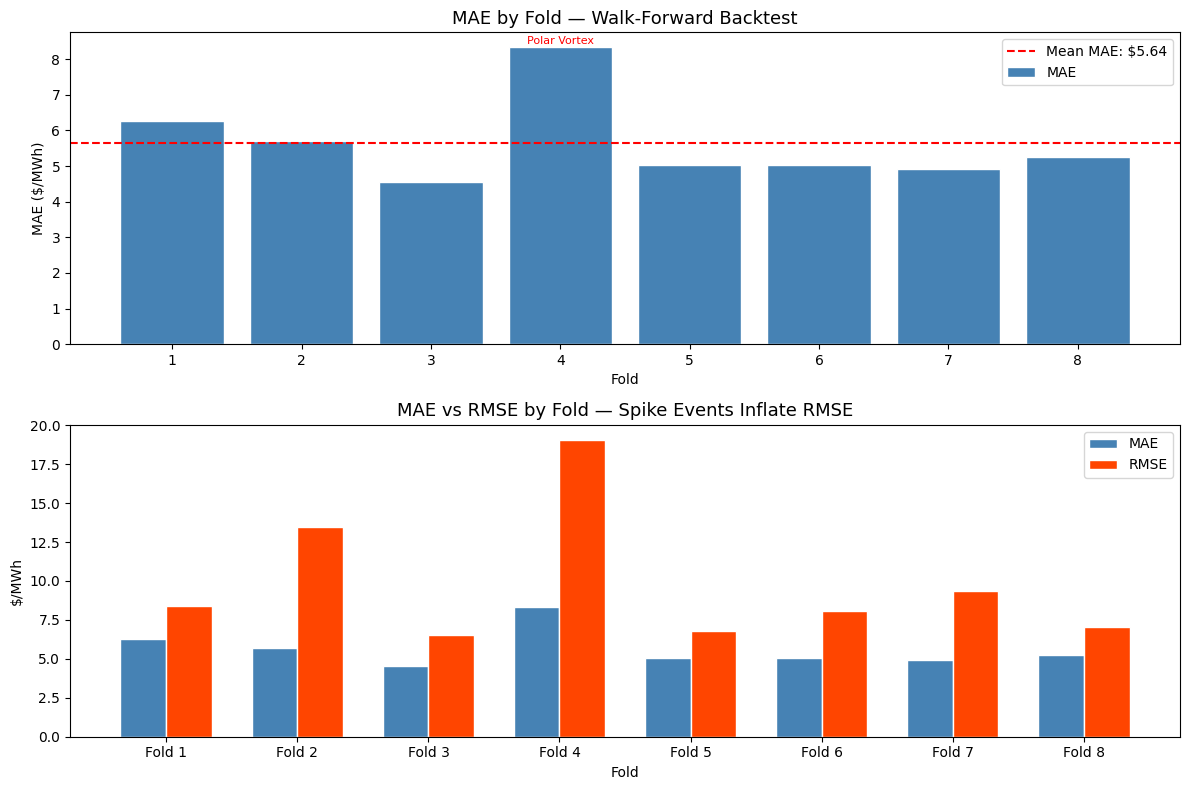

In [5]:
# --- Visualize Fold Performance ---
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

folds = results_df['fold']

# Top — MAE by fold
axes[0].bar(folds, results_df['mae'], color='steelblue',
            edgecolor='white', label='MAE')
axes[0].axhline(results_df['mae'].mean(), color='red',
                linestyle='--', linewidth=1.5,
                label=f"Mean MAE: ${results_df['mae'].mean():.2f}")
axes[0].set_title('MAE by Fold — Walk-Forward Backtest', fontsize=13)
axes[0].set_ylabel('MAE ($/MWh)')
axes[0].set_xlabel('Fold')
axes[0].set_xticks(folds)
axes[0].legend()

# Annotate worst fold
worst = results_df.loc[results_df['mae'].idxmax()]
'''
axes[0].annotate('Polar Vortex\n(Jan 2024)',
                 xy=(worst['fold'], worst['mae']),
                 xytext=(worst['fold']+0.3, worst['mae']+0.3),
                 fontsize=9, color='red')

'''
axes[0].text(worst['fold'], worst['mae'] + 0.1, 
             'Polar Vortex', 
             ha='center', fontsize=8, color='red')
# Bottom — MAE vs RMSE comparison
x = np.arange(len(folds))
width = 0.35
axes[1].bar(x - width/2, results_df['mae'],  width,
            label='MAE',  color='steelblue', edgecolor='white')
axes[1].bar(x + width/2, results_df['rmse'], width,
            label='RMSE', color='orangered', edgecolor='white')
axes[1].set_title('MAE vs RMSE by Fold — Spike Events Inflate RMSE', fontsize=13)
axes[1].set_ylabel('$/MWh')
axes[1].set_xlabel('Fold')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Fold {i}' for i in folds])
axes[1].legend()

plt.tight_layout()
plt.savefig('results/backtest_fold_performance.png', dpi=150)
plt.show()

- Fold 4 towers above everything — polar vortex, undeniable
- Folds 5–8 are remarkably consistent — model stabilizes as training data grows
- Bottom chart — Folds 2 and 4 have massive RMSE spikes while MAE stays moderate, confirming it's a small number of extreme hours causing the damage, not systematic error

In [6]:
# --- Save Backtest Results
results_df.to_csv('results/backtest_results.csv', index=False)
print("Backtest results saved.")
print("\nFinal Summary:")
print(results_df[['fold','test_start','test_end','mae','rmse']].to_string(index=False))

Backtest results saved.

Final Summary:
 fold test_start   test_end      mae      rmse
    1 2023-03-30 2023-06-18 6.273838  8.397265
    2 2023-06-18 2023-09-06 5.710211 13.471405
    3 2023-09-06 2023-11-25 4.542174  6.525018
    4 2023-11-25 2024-02-14 8.334994 19.068064
    5 2024-02-14 2024-05-04 5.040860  6.799158
    6 2024-05-04 2024-07-23 5.031702  8.089215
    7 2024-07-23 2024-10-11 4.909682  9.365355
    8 2024-10-11 2024-12-30 5.246962  7.048424
